# Spotify Music Intelligence

## Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore the Spotify datasets and uncover meaningful insights about songs, artists, genres, and musical trends.

Every visualization in this notebook answers a business question that could help Spotify make better decisions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

songs = pd.read_csv("../data/raw/data.csv")
artists = pd.read_csv("../data/raw/data_by_artist.csv")
genres = pd.read_csv("../data/raw/data_by_genres.csv")
years = pd.read_csv("../data/raw/data_by_year.csv")
songs_with_genres = pd.read_csv("../data/raw/data_w_genres.csv")

## Business Question 1

How are Spotify songs distributed by popularity?

This helps us understand whether most songs become popular or whether only a small percentage achieve high popularity.

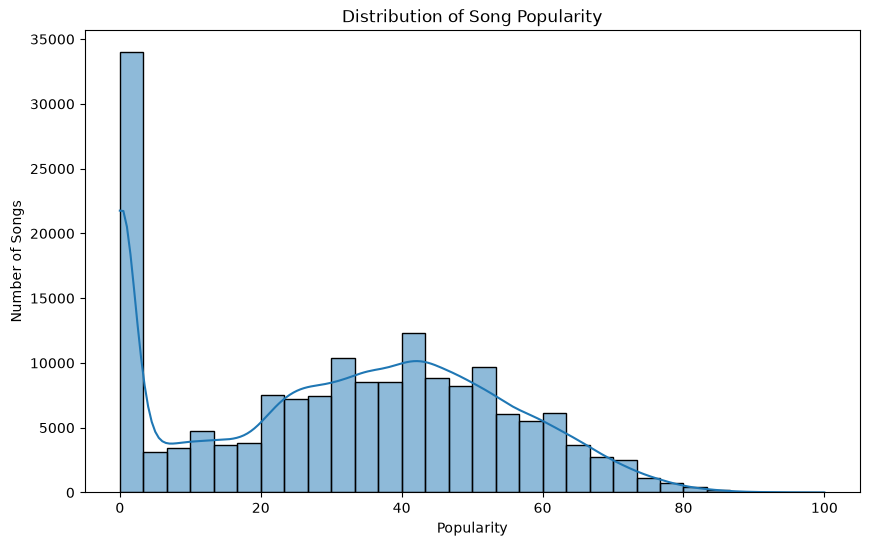

In [2]:
plt.figure(figsize=(10,6))

sns.histplot(
    songs["popularity"],
    bins=30,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

### Observation

The popularity distribution is right-skewed. Most songs have relatively low popularity, while only a small number achieve very high popularity, indicating that highly popular songs are relatively uncommon.

A significant spike at popularity **0** suggests that many songs in the dataset have little to no recent listener engagement. These are likely older, niche, or rarely streamed tracks. Another concentration of songs appears in the **30–50** popularity range, representing moderately popular songs, while the number of songs steadily decreases as popularity increases.

## Business Question 2

What are the most popular songs?

In [3]:
top_songs = songs.nlargest(10, "popularity")

top_songs[["name", "artists", "popularity"]]

,name,artists,popularity
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99
19618,Dynamite,['BTS'],97
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96
19610,positions,['Ariana Grande'],96
19612,What You Know Bout Love,['Pop Smoke'],96
19616,Blinding Lights,['The Weeknd'],96
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95
19620,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",95


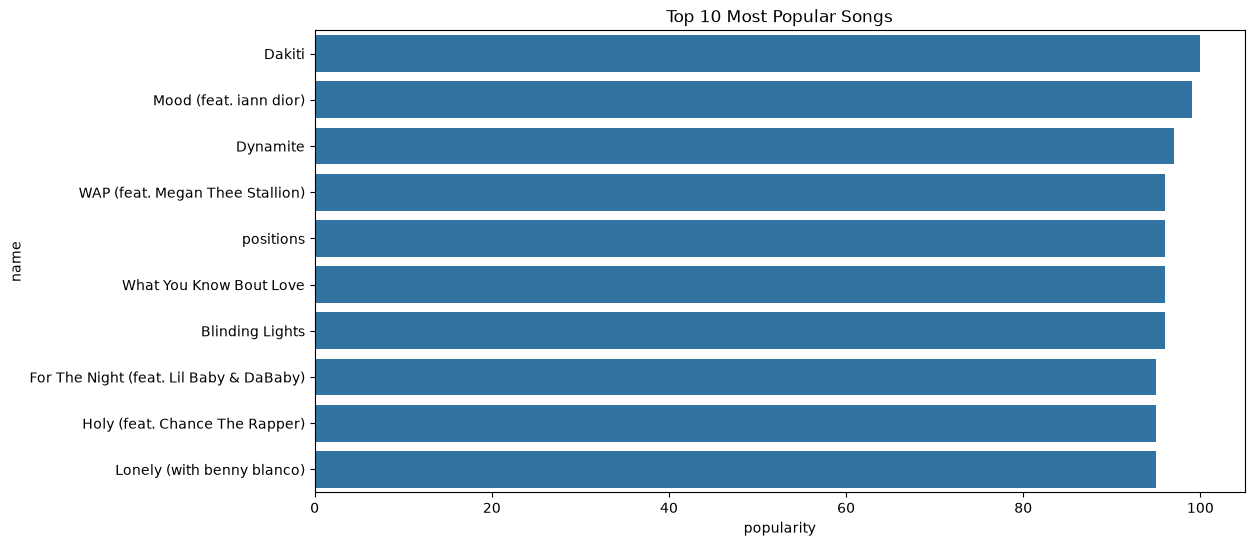

In [4]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_songs,
    x="popularity",
    y="name"
)

plt.title("Top 10 Most Popular Songs")

plt.show()

### Observation

The bar chart shows the top 10 most popular songs in the dataset, with popularity scores ranging from approximately 95 to 100. **Dakiti** is the most popular song, followed closely by **Mood (feat. iann dior)** and **Dynamite**. 

The small differences in popularity scores indicate that these songs were all highly successful and widely streamed during the period represented in the dataset. Overall, the chart highlights that only a few songs achieve exceptionally high popularity, making them stand out from the rest of the dataset.

## Business Question 3

Which artists have the highest average popularity?

In [5]:
top_artists = artists.sort_values(
    "popularity",
    ascending=False
).head(10)

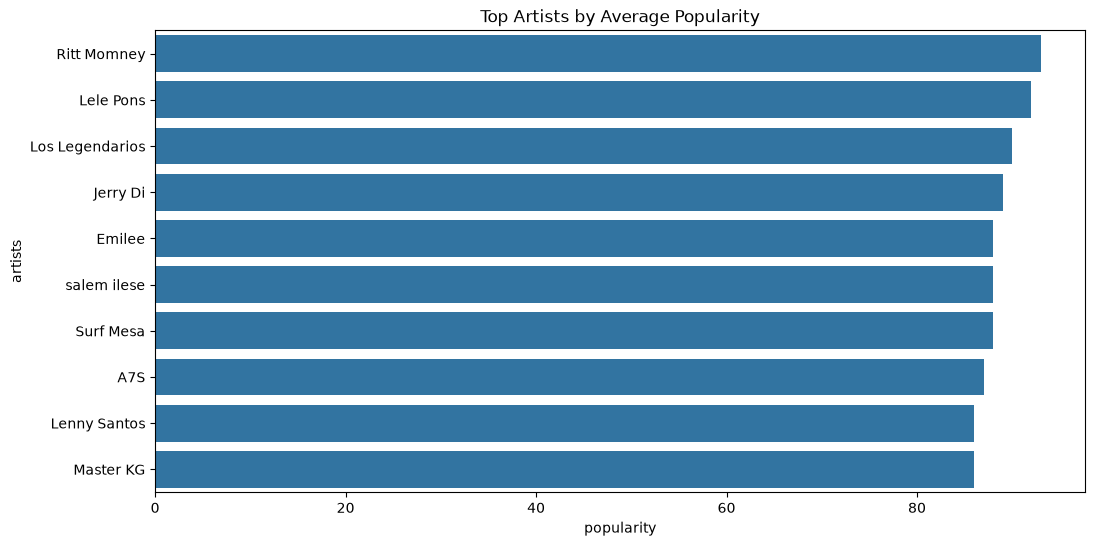

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_artists,
    x="popularity",
    y="artists"
)

plt.title("Top Artists by Average Popularity")

plt.show()

### Observation

The bar chart displays the top 10 artists with the highest average popularity in the dataset. **Ritt Momney** has the highest average popularity, followed closely by **Lele Pons** and **Los Legendarios**. 

The popularity scores of the top artists are relatively close, indicating that they all maintain a consistently high level of listener engagement. Overall, the chart suggests that only a small number of artists achieve exceptionally high average popularity, making them stand out from the rest of the artists in the dataset.

## Business Question 4

Which genres are the most popular?

In [7]:
top_genres = genres.sort_values(
    "popularity",
    ascending=False
).head(15)

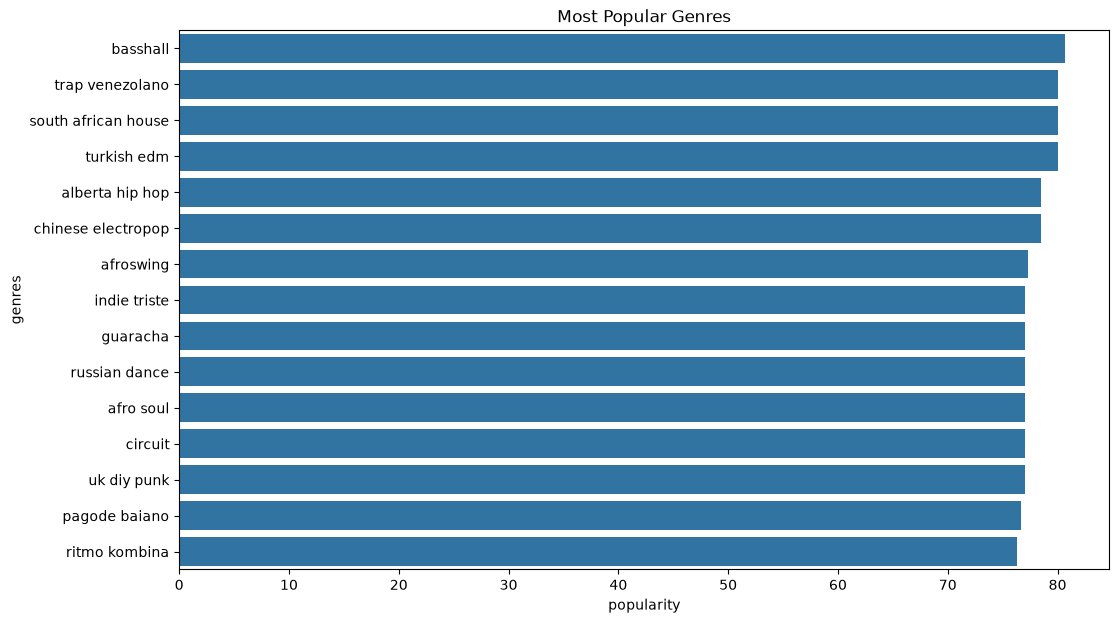

In [8]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_genres,
    x="popularity",
    y="genres"
)

plt.title("Most Popular Genres")

plt.show()

### Observation

The bar chart shows the top 15 genres with the highest average popularity in the dataset. **Basshall** ranks as the most popular genre, followed closely by **Trap Venezolano**, **South African House**, and **Turkish EDM**. 
    
The popularity scores of the leading genres are relatively close, indicating that several genres enjoy similar levels of listener engagement. Overall, the chart suggests that while a few genres consistently achieve high popularity, no single genre overwhelmingly dominates, reflecting a diverse range of popular music preferences among listeners.

## Business Question 5

Has music changed over time?

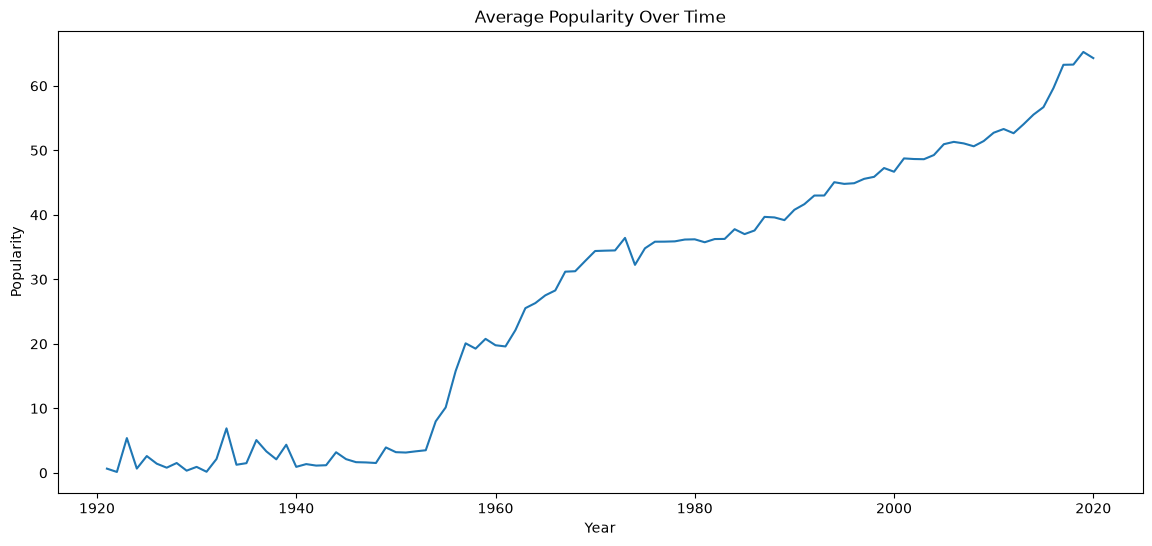

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    years["year"],
    years["popularity"]
)

plt.title("Average Popularity Over Time")

plt.xlabel("Year")

plt.ylabel("Popularity")

plt.show()

### Observation

The line chart shows that the average popularity of songs has generally increased over time. Songs released before the **1950s** have very low average popularity, while a noticeable rise begins in the **mid-1950s** and continues steadily through the following decades. The highest average popularity is observed in recent years (**2018–2020**), indicating that newer songs tend to receive greater listener engagement. Overall, the trend suggests that modern releases are significantly more popular than older songs in the dataset, likely due to changing listening habits and the influence of digital music streaming platforms.